𝐀𝐫𝐛𝐢𝐭𝐫𝐚𝐫𝐲 𝐕𝐚𝐥𝐮𝐞𝐬 𝐈𝐦𝐩𝐮𝐭𝐚𝐭𝐢𝐨𝐧

It consists of replacing NAN by an arbitrary values. This technique was derived from Kaggle competition.

In [248]:
import pandas as pd

In [249]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [250]:
def imput_nan(df,variable):
    df[variable+"_zero"]=df[variable].fillna(0)
    df[variable+'_hundred']=df[variable].fillna(100)

<Axes: >

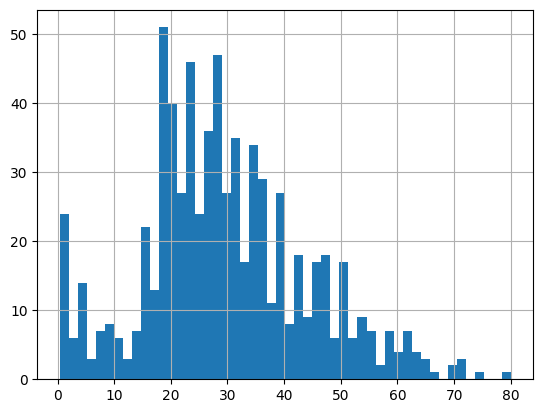

In [251]:
df['Age'].hist(bins=50)

2️⃣ Why do we use it?

We use arbitrary values when:

1. Missing values are important information
Example: Missing income may mean the person is unemployed.

2. We don't want to distort the distribution
Mean/median changes the distribution slightly.

3. Tree-based models handle it well

    * Decision Tree

    * Random Forest

    * XGBoost

3️⃣ When should you use it?

Use Arbitrary Value Imputation when:

✔ Missing values are very large in number
✔ You want the model to identify missing values separately
✔ Using tree-based algorithms

Example features:

 * Age

 * Salary

 * Loan amount

 * Credit score

4️⃣ When should you NOT use it?

Avoid it when using distance-based models like:

* KNN

* K-Means

* Linear Regression (sometimes)

Because extreme values like -999 can distort the model.

✅ Simple definition for interviews

Arbitrary Value Imputation is a technique used to replace missing values with a fixed value (usually extreme like -999 or 999) to indicate that the data was missing.

## 𝐇𝐨𝐰 𝐓𝐨 𝐇𝐚𝐧𝐝𝐥𝐞 𝐂𝐚𝐭𝐞𝐠𝐫𝐨𝐜𝐢𝐚𝐥 𝐌𝐢𝐬𝐬𝐢𝐧𝐠 𝐕𝐚𝐥𝐮𝐞𝐬

𝐅𝐫𝐞𝐪𝐮𝐞𝐧𝐭 𝐂𝐚𝐭𝐞𝐠𝐨𝐫𝐲 𝐈𝐦𝐩𝐮𝐭𝐚𝐭𝐢𝐨𝐧

In [252]:
df=pd.read_csv('train.csv',usecols=['BsmtQual','FireplaceQu','GarageType','SalePrice'])

In [253]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [254]:
df.shape

(1460, 4)

In [255]:
df.isnull().sum()

BsmtQual        37
FireplaceQu    690
GarageType      81
SalePrice        0
dtype: int64

In [256]:
df.isnull().mean()

BsmtQual       0.025342
FireplaceQu    0.472603
GarageType     0.055479
SalePrice      0.000000
dtype: float64

In [257]:
df.isnull().mean().sort_values(ascending=True)

SalePrice      0.000000
BsmtQual       0.025342
GarageType     0.055479
FireplaceQu    0.472603
dtype: float64

In [258]:
df.isnull().sum()

BsmtQual        37
FireplaceQu    690
GarageType      81
SalePrice        0
dtype: int64

 In BsmtQual and GarageType having less number of missing so we replace with most frequent variable


In [259]:
# In BsmtQual and GarageType having less number of missing so we replace with most frequent variable

df.groupby(['BsmtQual'])['BsmtQual'].count()

BsmtQual
Ex    121
Fa     35
Gd    618
TA    649
Name: BsmtQual, dtype: int64

<Axes: xlabel='BsmtQual'>

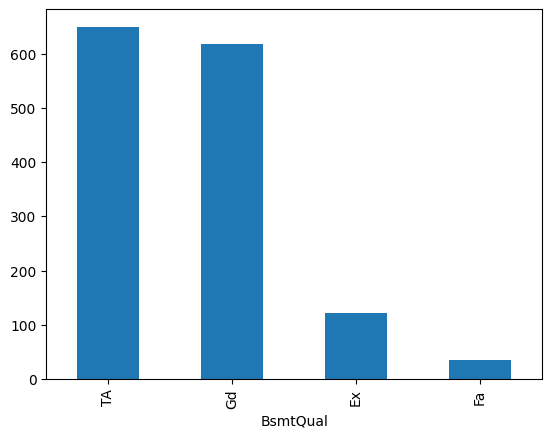

In [260]:
df.groupby(['BsmtQual'])['BsmtQual'].count().sort_values(ascending=False).plot.bar()

In [261]:
df['GarageType'].value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

<Axes: xlabel='GarageType'>

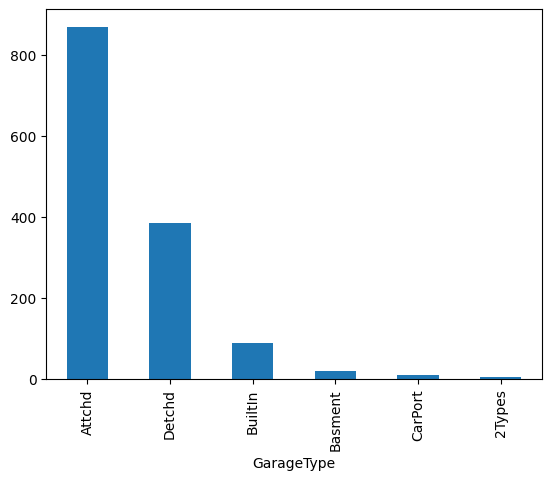

In [262]:
df['GarageType'].value_counts().plot.bar()

<Axes: xlabel='FireplaceQu'>

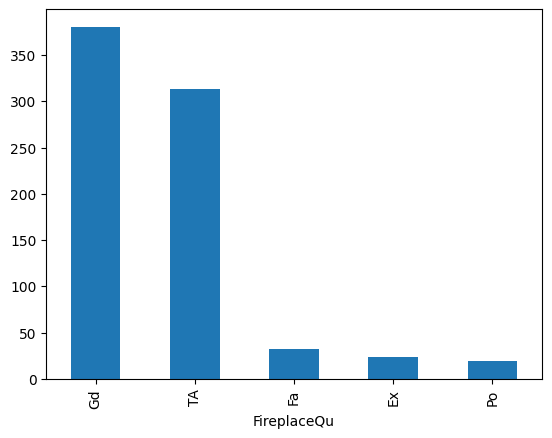

In [263]:
df['FireplaceQu'].value_counts().plot.bar()

In [264]:
df['GarageType'].value_counts().index[0]

'Attchd'

In [265]:
def impute_nan(df,variable):
    most_frequent_category=df[variable].value_counts().index[0]
    df[variable].fillna(most_frequent_category,inplace=True)

In [266]:
for feature in ['BsmtQual','GarageType','FireplaceQu']:
    impute_nan(df,feature)

C:\Users\hp\AppData\Local\Temp\ipykernel_14392\3113500501.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[variable].fillna(most_frequent_category,inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_14392\3113500501.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [267]:
df.isnull().mean()

BsmtQual       0.0
FireplaceQu    0.0
GarageType     0.0
SalePrice      0.0
dtype: float64

In [268]:
# another way to find most frequent variable
df['GarageType'].mode()[0]

'Attchd'

Advantages
1. Easy To implement
2. Faster way to implement

Disadvantages


3. Since we are using the more frequent labels, it may use them in an over represented way, if there are many nan's 
4. it distorts the relation of the most frequent label

𝗔𝗱𝗱𝗶𝗻𝗴 𝗮 𝘃𝗮𝗿𝗶𝗮𝗯𝗹𝗲 𝘁𝗼 𝗰𝗮𝗽𝘁𝘂𝗿𝗲 𝗡𝗔𝗡

if lot of missing values in your dataset use this technique

In [269]:
df=pd.read_csv('train.csv',usecols=['BsmtQual','FireplaceQu','GarageType','SalePrice'])
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [270]:
import numpy as np
df['BsmtQual_var']=np.where(df['BsmtQual'].isnull(),1,0)

In [271]:
df.head(13)

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var
0,Gd,NaN,Attchd,208500,0
1,Gd,TA,Attchd,181500,0
2,Gd,TA,Attchd,223500,0
3,TA,Gd,Detchd,140000,0
4,Gd,TA,Attchd,250000,0
5,Gd,NaN,Attchd,143000,0
6,Ex,Gd,Attchd,307000,0
7,Gd,TA,Attchd,200000,0
8,TA,TA,Detchd,129900,0
9,TA,TA,Attchd,118000,0


In [272]:
frequent= df['BsmtQual'].mode()[0]

In [273]:
df['BsmtQual_var'].fillna(frequent,inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_14392\2158859901.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BsmtQual_var'].fillna(frequent,inplace=True)


In [274]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var
0,Gd,NaN,Attchd,208500,0
1,Gd,TA,Attchd,181500,0
2,Gd,TA,Attchd,223500,0
3,TA,Gd,Detchd,140000,0
4,Gd,TA,Attchd,250000,0


In [275]:
df['FireplaceQu_var']=np.where(df['FireplaceQu'].isnull(),1,0)
frequent=df['FireplaceQu'].mode()[0]
df['FireplaceQu'].fillna(frequent,inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_14392\2284369591.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna(frequent,inplace=True)


In [276]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var,FireplaceQu_var
0,Gd,Gd,Attchd,208500,0,1
1,Gd,TA,Attchd,181500,0,0
2,Gd,TA,Attchd,223500,0,0
3,TA,Gd,Detchd,140000,0,0
4,Gd,TA,Attchd,250000,0,0


𝗦𝘂𝗽𝗽𝗼𝘀𝗲 𝗶𝗳 𝘆𝗼𝘂 𝗵𝗮𝘃𝗲 𝗺𝗼𝗿𝗲 𝗳𝗿𝗲𝗾𝘂𝗲𝗻𝘁 𝗰𝗮𝘁𝗲𝗴𝗼𝗿𝗶𝗲𝘀, 𝗪𝗲 𝗷𝘂𝘀𝘁 𝗿𝗲𝗽𝗹𝗮𝗰𝗲 𝗡𝗔𝗡 𝘄𝗶𝘁𝗵 𝗮 𝗻𝗲𝘄 𝗰𝗮𝘁𝗲𝗴𝗼𝗿𝘆

In [277]:
df=pd.read_csv('train.csv',usecols=['BsmtQual','FireplaceQu','GarageType','SalePrice'])
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [278]:
def impute_nan(df, variable):
    df[variable + "_newvar"] = np.where(df[variable].isnull(), "Missing", df[variable])



In [279]:
for feature in ['BsmtQual','GarageType','FireplaceQu']:
    impute_nan(df, feature)

In [280]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_newvar,GarageType_newvar,FireplaceQu_newvar
0,Gd,NaN,Attchd,208500,Gd,Attchd,Missing
1,Gd,TA,Attchd,181500,Gd,Attchd,TA
2,Gd,TA,Attchd,223500,Gd,Attchd,TA
3,TA,Gd,Detchd,140000,TA,Detchd,Gd
4,Gd,TA,Attchd,250000,Gd,Attchd,TA


In [282]:
df.drop(['BsmtQual','GarageType','FireplaceQu'],axis=1)
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_newvar,GarageType_newvar,FireplaceQu_newvar
0,Gd,NaN,Attchd,208500,Gd,Attchd,Missing
1,Gd,TA,Attchd,181500,Gd,Attchd,TA
2,Gd,TA,Attchd,223500,Gd,Attchd,TA
3,TA,Gd,Detchd,140000,TA,Detchd,Gd
4,Gd,TA,Attchd,250000,Gd,Attchd,TA
